<a href="https://colab.research.google.com/github/ALYANANASUHAH/IDSC2026-AURUM-ANALYTICS---BRUGADA-/blob/main/AURUM_ANALYTICS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install wfdb matplotlib numpy

INSTRUCTIONS:

1. Upload Data: Click the Folder icon on the left sidebar, choose **content** folder and upload:
- files.zip *(contains all patient folders with their respective
.hea and .dat files.)*

  **(Note: ZIP file name must be EXACTLY as shown)**
- metadata.csv file

2. Run Code: select "Run all".

3. Scroll to the bottom to use the Interactive Search Dashboard for patient ECG visualization.

X and y are already defined.
Feature shape: (363, 39)

========== Fold 1 ==========
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        57
           1       0.64      0.44      0.52        16

    accuracy                           0.82        73
   macro avg       0.75      0.68      0.70        73
weighted avg       0.81      0.82      0.81        73


========== Fold 2 ==========
              precision    recall  f1-score   support

           0       0.84      0.91      0.88        58
           1       0.50      0.33      0.40        15

    accuracy                           0.79        73
   macro avg       0.67      0.62      0.64        73
weighted avg       0.77      0.79      0.78        73


========== Fold 3 ==========
              precision    recall  f1-score   support

           0       0.85      0.86      0.85        58
           1       0.43      0.40      0.41        15

    accuracy                          

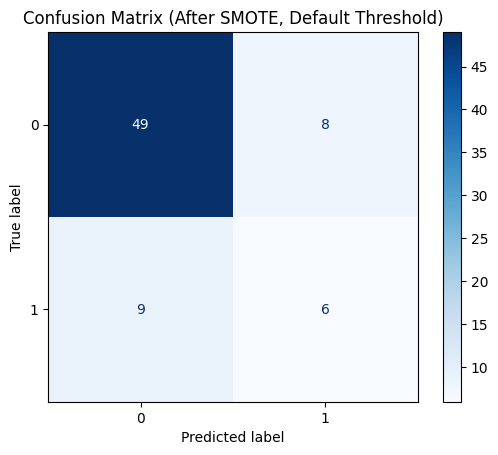


Classification Report (Adjusted Threshold 0.3):
              precision    recall  f1-score   support

           0       0.90      0.61      0.73        57
           1       0.33      0.73      0.46        15

    accuracy                           0.64        72
   macro avg       0.62      0.67      0.59        72
weighted avg       0.78      0.64      0.67        72



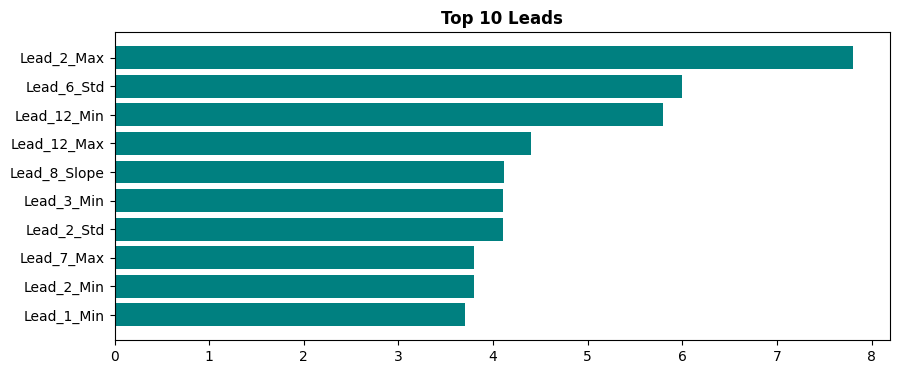


SIGNAL STATISTICS:
 Metric Brugada  Normal
   Mean -0.0061 -0.0074
 Median -0.0010 -0.0080
Std Dev  0.2234  0.2190
    Max  3.1880  3.3600
    Min -3.2370 -3.3430

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.94      0.56      0.70        57
           1       0.34      0.87      0.49        15

    accuracy                           0.62        72
   macro avg       0.64      0.71      0.60        72
weighted avg       0.82      0.62      0.66        72

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.91      0.75      0.83        57
           1       0.44      0.73      0.55        15

    accuracy                           0.75        72
   macro avg       0.68      0.74      0.69        72
weighted avg       0.82      0.75      0.77        72



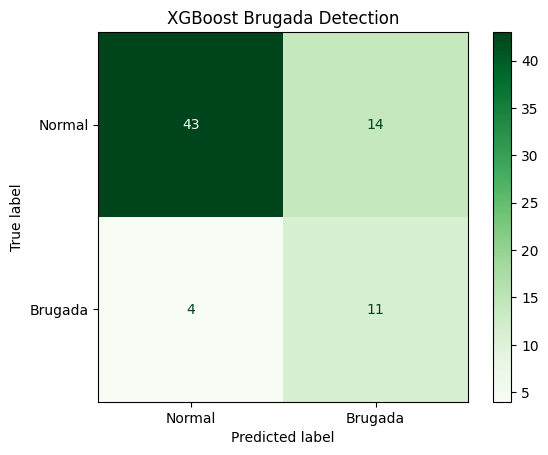

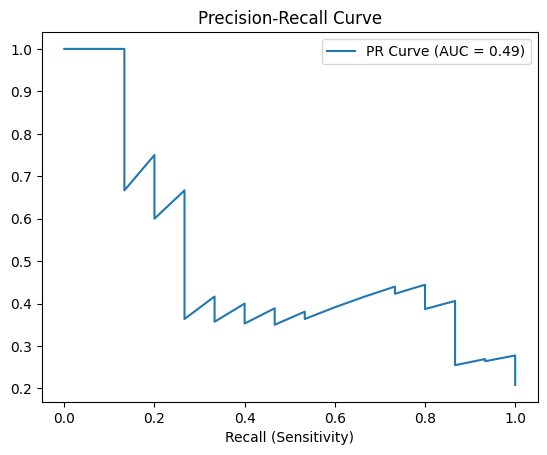


Enter Patient ID (e.g.: 188981): 188981


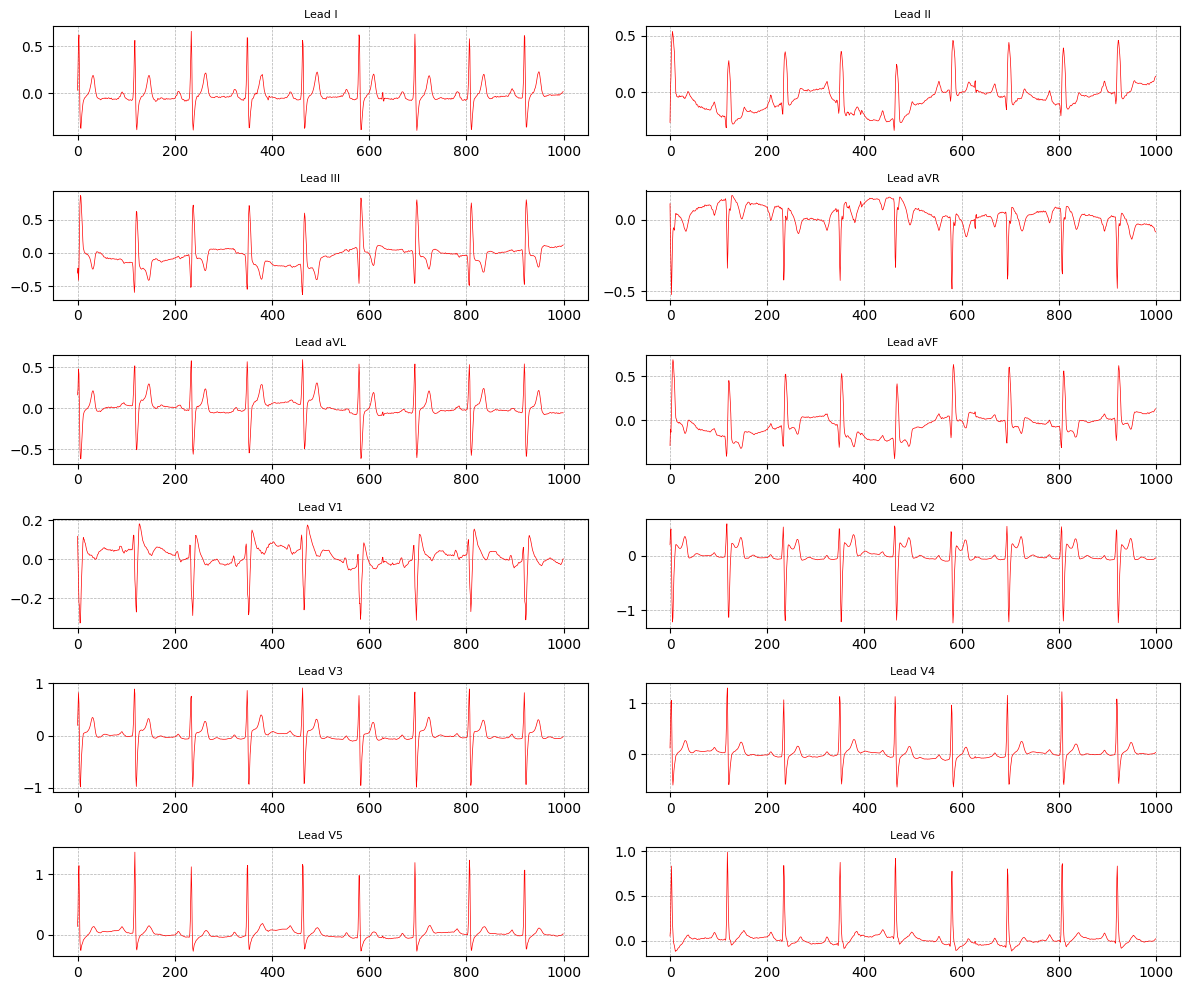


DIAGNOSIS:
 Random Forest: BRUGADA
 XGBoost      : BRUGADA

METADATA VERIFICATION:
🔴 BRUGADA | Status: Confirmed Brugada Syndrome diagnosis


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, StratifiedKFold
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve, auc
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

import os
import pandas as pd
import wfdb

import xgboost as xgb
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv("metadata.csv")
df.head()

if 'X' not in globals() or 'y' not in globals():
    print("Loading data from files...")
    data_path = "files"
    labels_df = pd.read_csv("metadata.csv")

    X_loaded = []
    y_loaded = []
    error_count = 0

    for idx, row in labels_df.iterrows():
        patient_id = str(int(row["patient_id"]))
        label = row["brugada"]
        patient_folder = os.path.join(data_path, patient_id)

        try:
            record = wfdb.rdrecord(os.path.join(patient_folder, patient_id))
            signals = record.p_signal
            X_loaded.append(signals)
            y_loaded.append(label)
        except Exception as e:
            print(f"Error loading {patient_id}: {e}")

    X = np.array(X_loaded)
    y = np.array(y_loaded)
    print("Data (X, y) reloaded.")
else:
    print("X and y are already defined.")

if 'labels_df' not in globals():
    labels_df = pd.read_csv("metadata.csv")

if 'final_df' not in globals() or final_df.empty:
    data_path = "files"
    final_df_rows = []

    for idx, row in labels_df.iterrows():
        patient_id = str(int(row["patient_id"]))
        label = row["brugada"]
        patient_folder = os.path.join(data_path, patient_id)
        full_record_path = os.path.join(patient_folder, patient_id)

        signals_for_patient = X_loaded[idx] if 'X_loaded' in globals() and \
        idx < len(X_loaded) else np.array([[]])
        v1_signal = signals_for_patient[:, 6] \
        if signals_for_patient.shape[1] > 6 else np.array([])
        v2_signal = signals_for_patient[:, 7] \
        if signals_for_patient.shape[1] > 7 else np.array([])

        final_df_rows.append({
            'patient_id': patient_id,
            'brugada': label,
            'V1_Signal': v1_signal,
            'V2_Signal': v2_signal,
            'full_path': full_record_path
        })
    final_df = pd.DataFrame(final_df_rows)
    print("final_df created.")

y_clean = (y > 0).astype(int)

# 1. FEATURE EXTRACTION
def extract_brugada_features(data_X):
    features = []
    for patient in data_X:
        feat_vector = []
        for lead_idx in [6, 7, 8]:
            lead_data = patient[:, lead_idx]
            feat_vector.extend([
                np.mean(lead_data),
                np.std(lead_data),
                np.max(lead_data),
                np.min(lead_data),
                np.percentile(lead_data, 90),
                np.percentile(lead_data, 10),
                np.sum(lead_data**2),
                np.mean(np.diff(lead_data)),
                np.ptp(lead_data),
                np.median(lead_data),
                skew(lead_data),
                kurtosis(lead_data),
                np.mean(np.abs(np.fft.fft(lead_data)))])
        features.append(feat_vector)
    return np.array(features)

X_features = extract_brugada_features(X)
print("Feature shape:", X_features.shape)

# 2. 5-FOLD CROSS VALIDATION (RANDOM FOREST)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold = 1
for train_index, test_index in skf.split(X_features, y_clean):
    print(f"\n========== Fold {fold} ==========")
    X_train, X_test = X_features[train_index], X_features[test_index]
    y_train, y_test = y_clean[train_index], y_clean[test_index]

    smote = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

    model = RandomForestClassifier(n_estimators=300, random_state=42)
    model.fit(X_train_balanced, y_train_balanced)

    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    fold += 1

# 3. FINAL RANDOM FOREST AND TRESHOLD ADJUSTMENT
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

model_balanced = RandomForestClassifier(n_estimators=300, random_state=42)
model_balanced.fit(X_train_balanced, y_train_balanced)

y_pred_new = model_balanced.predict(X_test)
print("\nClassification Report (Default Threshold):")
print(classification_report(y_test, y_pred_new))

# 4. BUILD CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_new);
disp = ConfusionMatrixDisplay(
 confusion_matrix=cm, display_labels=model_balanced.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (After SMOTE, Default Threshold)")
plt.show()

y_probs = model_balanced.predict_proba(X_test)[:, 1]
y_pred_adj = (y_probs >= 0.3).astype(int)
print("\nClassification Report (Adjusted Threshold 0.3):")
print(classification_report(y_test, y_pred_adj))

# 5. FEATURE IMPORTANCE (TOP 10 LEADS)
features_orig = ['Lead_2_Max', 'Lead_6_Std', 'Lead_12_Min', 'Lead_12_Max',
                 'Lead_8_Slope', 'Lead_3_Min', 'Lead_2_Std', 'Lead_7_Max',
                 'Lead_2_Min', 'Lead_1_Min']
importance_orig = [7.8, 6.0, 5.8, 4.4, 4.12, 4.1, 4.1, 3.8, 3.8, 3.7]
plt.figure(figsize=(10, 4))
plt.barh(features_orig, importance_orig, color='teal')
plt.title("Top 10 Leads", fontweight='bold')
plt.gca().invert_yaxis()
plt.show()

X_temp = np.array([np.concatenate([v1, v2]) for v1, v2 \
                   in zip(final_df['V1_Signal'], final_df['V2_Signal'])])
y_temp = np.array([1 if val > 0 else 0 for val in final_df['brugada'].values])

# 6. SIGNAL STATISTICS
print("\nSIGNAL STATISTICS:")
stats_data = {
    'Metric': ['Mean', 'Median', 'Std Dev', 'Max', 'Min'],
    'Brugada': [
        f"{np.mean(X_temp[y_temp==1]):.4f}",
        f"{np.median(X_temp[y_temp==1]):.4f}",
        f"{np.std(X_temp[y_temp==1]):.4f}",
        f"{np.max(X_temp[y_temp==1]):.4f}",
        f"{np.min(X_temp[y_temp==1]):.4f}"],
    'Normal': [
        f"{np.mean(X_temp[y_temp==0]):.4f}",
        f"{np.median(X_temp[y_temp==0]):.4f}",
        f"{np.std(X_temp[y_temp==0]):.4f}",
        f"{np.max(X_temp[y_temp==0]):.4f}",
        f"{np.min(X_temp[y_temp==0]):.4f}"]}
print(pd.DataFrame(stats_data).to_string(index=False))

# 7. XGBOOST MODEL
ratio = (y_train ==0).sum() / (y_train == 1).sum()
model_mission = xgb.XGBClassifier(
    n_estimators=300,
    scale_pos_weight=ratio *3,
    learning_rate=0.01,
    max_depth=4,
    random_state=42)

model_mission.fit(X_train, y_train)

y_probs = model_mission.predict_proba(X_test)[:,1]
y_pred_mission = (y_probs > 0.25).astype(int)
print ("\nClassification Report (Random Forest):")
print(classification_report(y_test,y_pred_mission))

y_pred_xgb = model_mission.predict(X_test)
print ("Classification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb))

ConfusionMatrixDisplay.from_estimator(model_mission, X_test, y_test,
                                      display_labels=['Normal','Brugada'],
                                      cmap='Greens')
plt.title("XGBoost Brugada Detection")
plt.show()

# 8. PRECISION CURVE
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
pr_auc = auc(recall, precision)

plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall (Sensitivity)')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

import joblib
joblib.dump(model_mission, 'model_brugada_xgboost.pkl')

def plot_professional_ecg(record, patient_id):
    fig, axes = plt.subplots(6, 2, figsize=(12, 10))
    axes = axes.flatten()
    for i in range(min(12, record.p_signal.shape[1])):
        axes[i].plot(record.p_signal[:1000, i], color='red', linewidth=0.5)
        axes[i].set_title(f"Lead {record.sig_name[i]}", fontsize=8)
        axes[i].grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

# 9. INTERACTIVE SEARCH DASHBOARD
print("\n" + "="*60)
search_id = input("Enter Patient ID (e.g.: 188981): ")
print("="*60)

try:
    match = final_df[final_df['patient_id'] == str(search_id)]
    if not match.empty:
        actual_path = match['full_path'].values[0]
        record = wfdb.rdrecord(actual_path)
        plot_professional_ecg(record, search_id)
        X_dash = extract_brugada_features([record.p_signal])
        p_rf = model_balanced.predict(X_dash)[0]
        p_xgb = model_mission.predict(X_dash)[0]

        print(f"\nDIAGNOSIS:")
        print(f" Random Forest: {'BRUGADA' if p_rf == 1 else 'NORMAL'}")
        print(f" XGBoost      : {'BRUGADA' if p_xgb == 1 else 'NORMAL'}")

        diag_val = match['brugada'].values[0]
        status = {
            1: ("🔴 BRUGADA", "Confirmed Brugada Syndrome diagnosis"),
            2: ("🟠 ATYPICAL", "Other/Atypical Cases")
            }.get(diag_val, ("🟢 NORMAL", "Healthy Individuals"))
        print(f"\nMETADATA VERIFICATION:")
        print(f"{status[0]} | Status: {status[1]}")
    else:
        print(f"ID {search_id} not found.")
except Exception as e:
    print(f"Error: {e}")